# Zomato vs Swiggy Integrated Performance Analysis

This notebook integrates two layers of analysis:
1. **Google Trends search interest** (web interest)
2. **Financial performance data** (Transaction Value, Monthly Transacting Users, Adjusted Revenue, EBITDA Margin)

We analyze exactly **5 core business questions** designed to uncover competitive dynamics and verify if search momentum functions as a leading indicator of business performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


## Data Loading and Setup

In [2]:
df_fin = pd.read_csv("../data/raw/financial_performance.csv")
df_trends = pd.read_csv("../data/raw/google_trends_raw.csv")

# Calculate YoY metrics and Take Rates (Revenue Rate)
df_fin['Transaction_Value_YoY'] = df_fin.groupby('Company')['Transaction_Value'].pct_change(4) * 100
df_fin['MTU_YoY'] = df_fin.groupby('Company')['MTU'].pct_change(4) * 100
df_fin['Adjusted_Revenue_YoY'] = df_fin.groupby('Company')['Adjusted_Revenue'].pct_change(4) * 100
df_fin['Revenue_Rate'] = (df_fin['Adjusted_Revenue'] / df_fin['Transaction_Value']) * 100

print("Financials shape:", df_fin.shape)
print("Trends shape:", df_trends.shape)


Financials shape: (24, 11)
Trends shape: (61, 3)


## Step 1: Data Integration & Indian Fiscal Calendar Alignment

We map the monthly Google Trends dates into Indian Fiscal Quarters (April to March):
- **Q1**: Apr - Jun
- **Q2**: Jul - Sep
- **Q3**: Oct - Dec
- **Q4**: Jan - Mar

Importantly, we compute the 1-quarter lagged search interest to test if search interest is a leading indicator.

In [3]:
df_trends['Time'] = pd.to_datetime(df_trends['Time'])
df_trends = df_trends.set_index('Time').sort_index()

def get_fy_quarter(date):
    if date.month in [4, 5, 6]:
        return "Q1"
    elif date.month in [7, 8, 9]:
        return "Q2"
    elif date.month in [10, 11, 12]:
        return "Q3"
    else:
        return "Q4"

df_trends['FY_Quarter'] = df_trends.index.map(get_fy_quarter)
df_trends['FY'] = df_trends.index.year + (df_trends.index.month >= 4).astype(int)
df_trends['Quarter'] = df_trends['FY_Quarter'] + " FY" + df_trends['FY'].astype(str).str[-2:]

# Aggregate trends to quarterly average search interest (including pre-FY24)
quarterly_trends = df_trends.groupby('Quarter')[['Zomato', 'Swiggy']].mean().reset_index()
quarterly_trends = quarterly_trends.rename(
    columns={"Zomato": "Zomato_Search_Interest", "Swiggy": "Swiggy_Search_Interest"}
)

# Convert to long format
trends_long = quarterly_trends.melt(
    id_vars="Quarter",
    value_vars=["Zomato_Search_Interest", "Swiggy_Search_Interest"],
    var_name="Search_Company",
    value_name="Search_Interest"
)
trends_long['Company'] = trends_long['Search_Company'].str.replace('_Search_Interest', '', regex=False)
trends_long = trends_long[['Quarter', 'Company', 'Search_Interest']]

# Quarter chronological ordering helper
def quarter_to_date(q_str):
    parts = q_str.split(" ")
    q, fy = parts[0], int(parts[1][2:])
    year = 2000 + fy
    if q == "Q1": return pd.Timestamp(year - 1, 4, 1)
    elif q == "Q2": return pd.Timestamp(year - 1, 7, 1)
    elif q == "Q3": return pd.Timestamp(year - 1, 10, 1)
    elif q == "Q4": return pd.Timestamp(year, 1, 1)

trends_long['Date_Key'] = trends_long['Quarter'].map(quarter_to_date)
trends_long = trends_long.sort_values(by=['Company', 'Date_Key']).reset_index(drop=True)

# Compute 1-quarter lagged search interest
trends_long['Search_Interest_Lag1'] = trends_long.groupby('Company')['Search_Interest'].shift(1)

# Merge with financials
df_fin['Date_Key'] = df_fin['Quarter'].map(quarter_to_date)
analysis_df = pd.merge(
    df_fin,
    trends_long[['Quarter', 'Company', 'Search_Interest', 'Search_Interest_Lag1']],
    on=['Quarter', 'Company'],
    how='left'
)
analysis_df = analysis_df.sort_values(by=['Company', 'Date_Key']).reset_index(drop=True)
analysis_df


,Company,Quarter,Transaction_Value,Adjusted_Revenue,MTU,Contribution_Margin,Adjusted_EBITDA_Margin,Transaction_Value_YoY,MTU_YoY,Adjusted_Revenue_YoY,Revenue_Rate,Date_Key,Search_Interest,Search_Interest_Lag1
0,Swiggy,Q1 FY24,5959,1455,12.6,5.2,-0.7,NaN,NaN,NaN,24.416848,2023-04-01,38.333333,36.666667
1,Swiggy,Q2 FY24,6275,1535,12.9,5.1,-0.8,NaN,NaN,NaN,24.462151,2023-07-01,40.666667,38.333333
2,Swiggy,Q3 FY24,6238,1533,12.5,5.9,0.3,NaN,NaN,NaN,24.575184,2023-10-01,37.333333,40.666667
3,Swiggy,Q4 FY24,6246,1559,12.9,6.7,0.5,NaN,NaN,NaN,24.959974,2024-01-01,41.000000,37.333333
4,Swiggy,Q1 FY25,6808,1730,14.0,6.4,0.8,14.247357,11.111111,18.900344,25.411281,2024-04-01,42.333333,41.000000
5,Swiggy,Q2 FY25,7191,1808,14.7,6.6,1.6,14.597610,13.953488,17.785016,25.142539,2024-07-01,48.000000,42.333333
6,Swiggy,Q3 FY25,7436,1860,14.9,7.4,2.5,19.204873,19.200000,21.330724,25.013448,2024-10-01,65.000000,48.000000
7,Swiggy,Q4 FY25,7347,1867,15.1,7.8,2.9,17.627281,17.054264,19.756254,25.411733,2025-01-01,50.000000,65.000000
8,Swiggy,Q1 FY26,8086,2080,16.3,7.3,2.4,18.772033,16.428571,20.231214,25.723473,2025-04-01,47.000000,50.000000
9,Swiggy,Q2 FY26,8542,2206,17.2,7.3,2.8,18.787373,17.006803,22.013274,25.825334,2025-07-01,45.000000,47.000000


### Question 1: Market Scale & Growth

**Who is larger in food delivery transaction scale (Transaction Value), and who is growing faster YoY?**

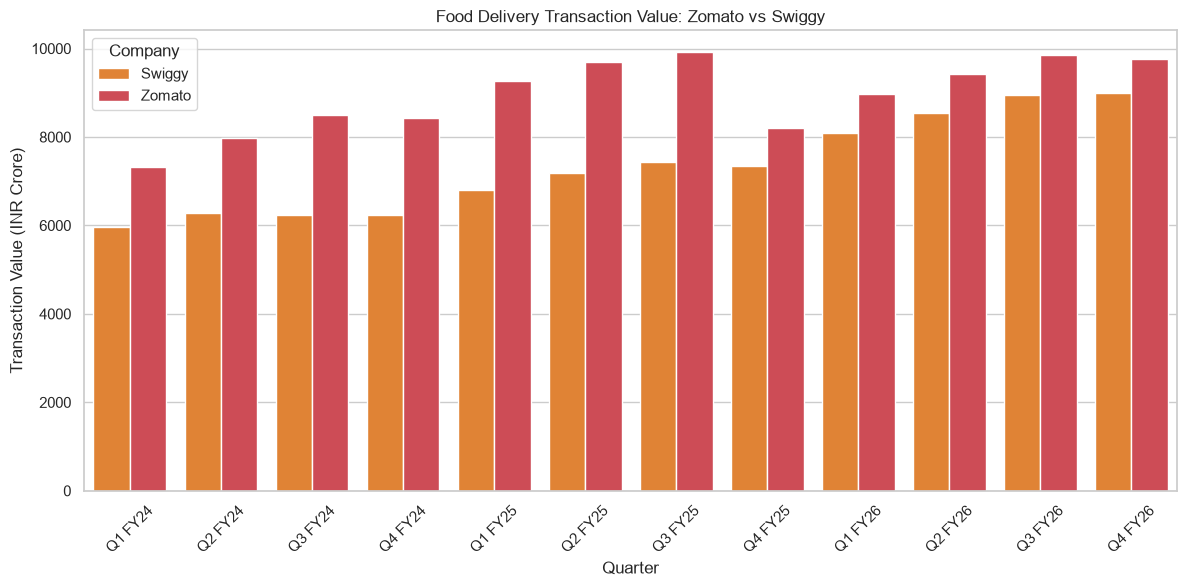

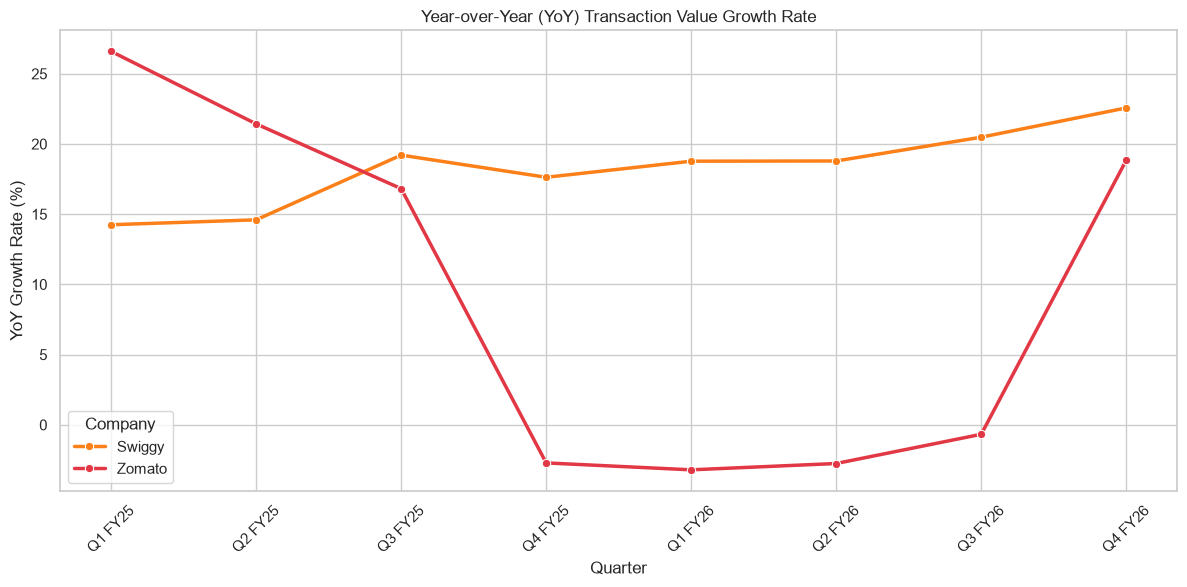

=== Q4 FY26 Transaction Scale and YoY Growth ===
Company  Transaction_Value  Transaction_Value_YoY
 Swiggy               9005              22.567034
 Zomato               9757              18.842875


In [4]:
# Bar chart comparison of Transaction Value
plt.figure(figsize=(12, 6))
sns.barplot(
    data=analysis_df,
    x="Quarter", y="Transaction_Value", hue="Company",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}
)
plt.title("Food Delivery Transaction Value: Zomato vs Swiggy")
plt.ylabel("Transaction Value (INR Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# YoY Growth comparison
growth_df = analysis_df.dropna(subset=['Transaction_Value_YoY'])
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=growth_df,
    x="Quarter", y="Transaction_Value_YoY", hue="Company", marker="o",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, linewidth=2.5
)
plt.title("Year-over-Year (YoY) Transaction Value Growth Rate")
plt.ylabel("YoY Growth Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print specific comparisons
latest = analysis_df[analysis_df['Quarter'] == 'Q4 FY26']
print("=== Q4 FY26 Transaction Scale and YoY Growth ===")
print(latest[['Company', 'Transaction_Value', 'Transaction_Value_YoY']].to_string(index=False))


### Question 2: User Traction & Engagement

**How do the monthly transacting users (MTU) compare, and is user growth the primary driver of transaction growth?**

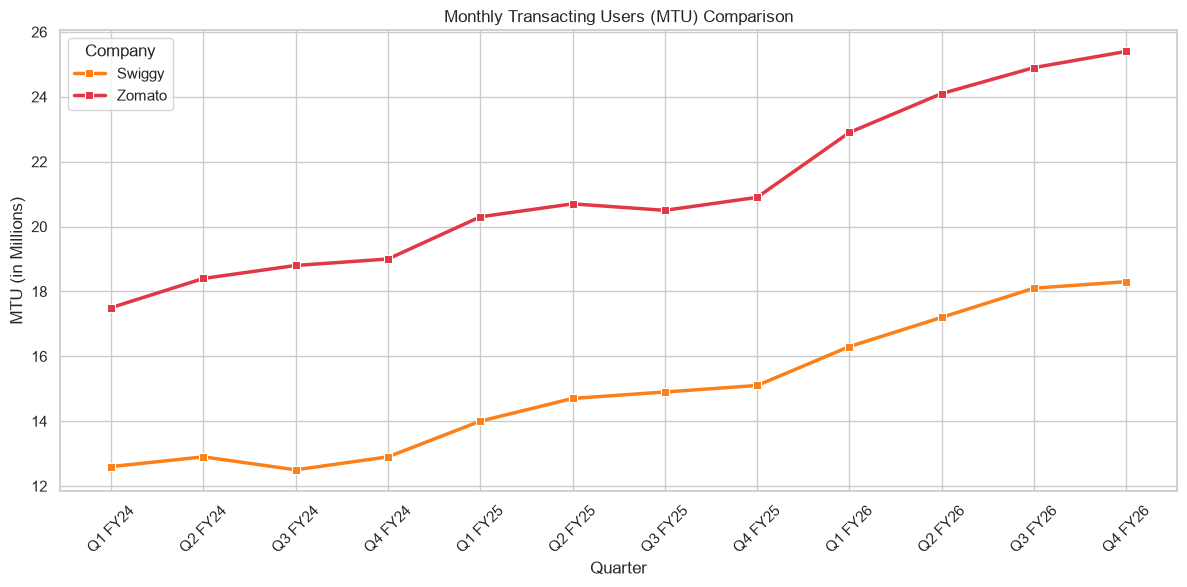

=== User Growth to Transaction Volume Correlation ===
Zomato: 0.7334
Swiggy: 0.9967


In [5]:
# Line chart of Monthly Transacting Users (MTU)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analysis_df,
    x="Quarter", y="MTU", hue="Company", marker="s",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, linewidth=2.5
)
plt.title("Monthly Transacting Users (MTU) Comparison")
plt.ylabel("MTU (in Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation between User count (MTU) and Transaction Value
print("=== User Growth to Transaction Volume Correlation ===")
for company in ['Zomato', 'Swiggy']:
    comp_df = analysis_df[analysis_df['Company'] == company]
    corr = comp_df['MTU'].corr(comp_df['Transaction_Value'])
    print(f"{company}: {corr:.4f}")


### Question 3: Monetization & Revenue Efficiency

**Who is more efficient at converting transactions into revenue (Take Rate / Revenue Rate), and how has this evolved?**

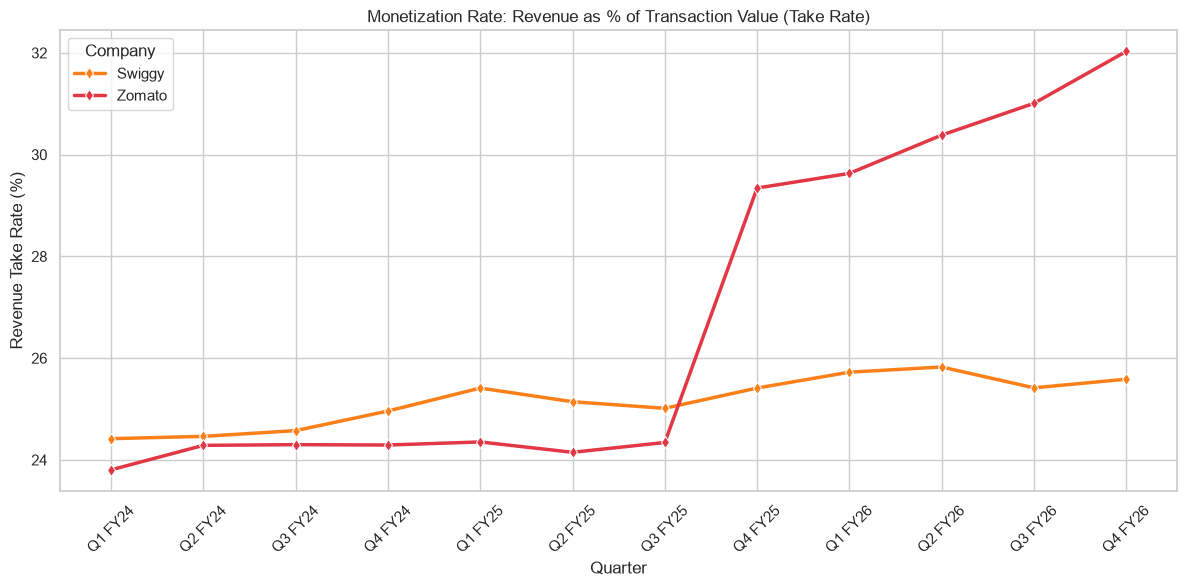

=== Monetization Rate Descriptive Statistics ===
              mean        min        max       std
Company                                           
Swiggy   25.161961  24.416848  25.825334  0.483963
Zomato   26.826301  23.804318  32.028287  3.292567


In [6]:
# Line chart of Revenue Rate (monetization efficiency)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analysis_df,
    x="Quarter", y="Revenue_Rate", hue="Company", marker="d",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, linewidth=2.5
)
plt.title("Monetization Rate: Revenue as % of Transaction Value (Take Rate)")
plt.ylabel("Revenue Take Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Descriptive stats on Revenue Take Rate
print("=== Monetization Rate Descriptive Statistics ===")
stats = analysis_df.groupby('Company')['Revenue_Rate'].agg(['mean', 'min', 'max', 'std'])
print(stats)


### Question 4: Profitability Path

**How have the adjusted EBITDA margins evolved, and which company shows a more stable path to profitability?**

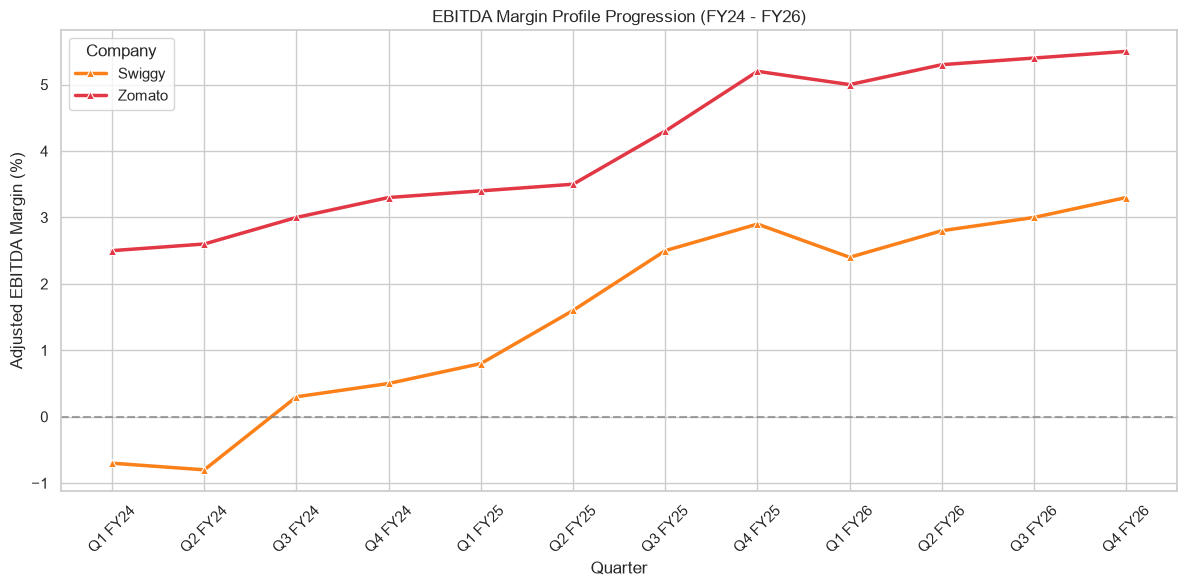

=== Margin Progression (Q1 FY24 vs Q4 FY26) ===
Company Quarter  Adjusted_EBITDA_Margin
 Swiggy Q1 FY24                    -0.7
 Swiggy Q4 FY26                     3.3
 Zomato Q1 FY24                     2.5
 Zomato Q4 FY26                     5.5


In [7]:
# EBITDA Margin path
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analysis_df,
    x="Quarter", y="Adjusted_EBITDA_Margin", hue="Company", marker="^",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, linewidth=2.5
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("EBITDA Margin Profile Progression (FY24 - FY26)")
plt.ylabel("Adjusted EBITDA Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== Margin Progression (Q1 FY24 vs Q4 FY26) ===")
prog = analysis_df[analysis_df['Quarter'].isin(['Q1 FY24', 'Q4 FY26'])]
print(prog[['Company', 'Quarter', 'Adjusted_EBITDA_Margin']].sort_values(by=['Company', 'Quarter']).to_string(index=False))


### Question 5: Search Interest as a Leading Indicator

**Does Google Search Interest correlate with business performance in the same quarter, and does a 1-quarter lag suggest that search interest acts as a leading indicator of future business performance?**

=== Google Search Correlation Matrix ===
Company  Same_Quarter_TV_Corr  Lagged_Quarter_TV_Corr  Same_Quarter_MTU_Corr  Lagged_Quarter_MTU_Corr
 Zomato             -0.232600               -0.212913              -0.697797                -0.489883
 Swiggy              0.287768                0.447177               0.260551                 0.443949


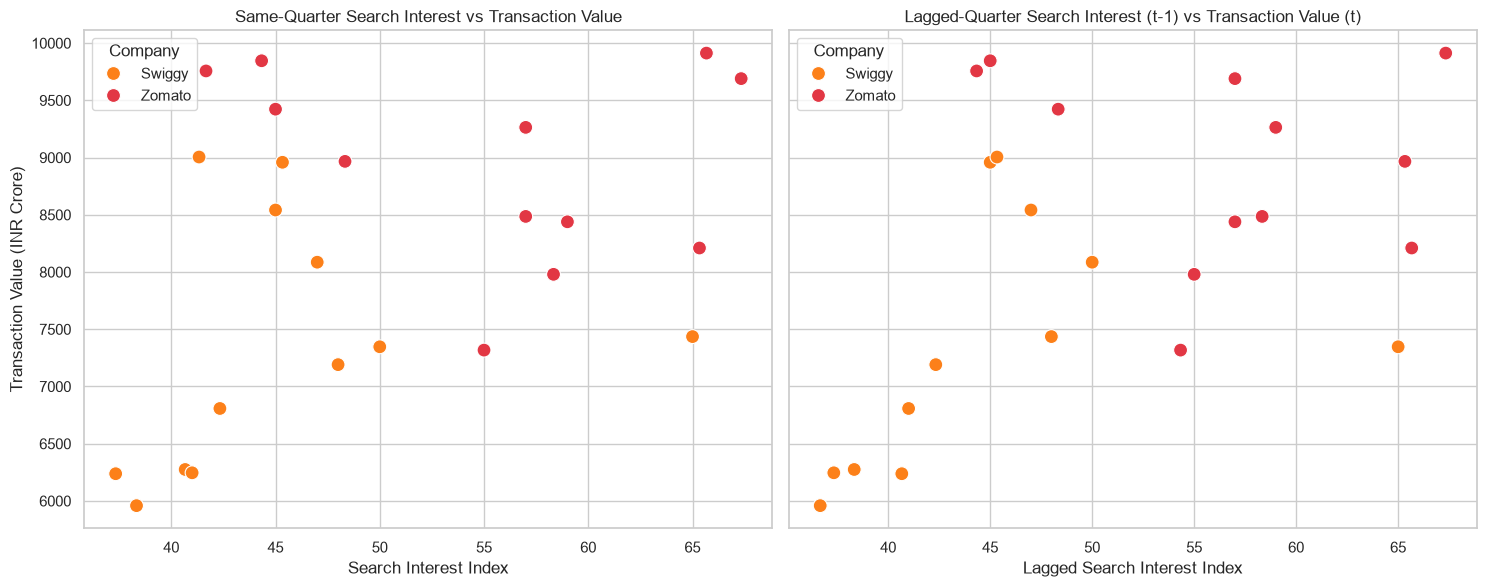

In [8]:
# Print correlation tables
print("=== Google Search Correlation Matrix ===")
corrs = []
for company in ['Zomato', 'Swiggy']:
    comp_df = analysis_df[analysis_df['Company'] == company]
    
    same_tv = comp_df['Search_Interest'].corr(comp_df['Transaction_Value'])
    lag_tv = comp_df['Search_Interest_Lag1'].corr(comp_df['Transaction_Value'])
    same_mtu = comp_df['Search_Interest'].corr(comp_df['MTU'])
    lag_mtu = comp_df['Search_Interest_Lag1'].corr(comp_df['MTU'])
    
    corrs.append({
        "Company": company,
        "Same_Quarter_TV_Corr": same_tv,
        "Lagged_Quarter_TV_Corr": lag_tv,
        "Same_Quarter_MTU_Corr": same_mtu,
        "Lagged_Quarter_MTU_Corr": lag_mtu
    })

corrs_df = pd.DataFrame(corrs)
print(corrs_df.to_string(index=False))

# Visualizing Same vs Lagged search to Transaction Value
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.scatterplot(
    data=analysis_df, x="Search_Interest", y="Transaction_Value", hue="Company",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, s=100, ax=axes[0]
)
axes[0].set_title("Same-Quarter Search Interest vs Transaction Value")
axes[0].set_xlabel("Search Interest Index")
axes[0].set_ylabel("Transaction Value (INR Crore)")

sns.scatterplot(
    data=analysis_df, x="Search_Interest_Lag1", y="Transaction_Value", hue="Company",
    palette={"Zomato": "#E23744", "Swiggy": "#FC8019"}, s=100, ax=axes[1]
)
axes[1].set_title("Lagged-Quarter Search Interest (t-1) vs Transaction Value (t)")
axes[1].set_xlabel("Lagged Search Interest Index")

plt.tight_layout()
plt.show()


## Export Master Dataset for Power BI Import

We save this compiled, verified dataframe with a structured `Date_Key` for Power BI date-table parsing.

In [9]:
# Output file path
out_path = "../data/processed/power_bi_master.csv"

# Save to processed folder
os.makedirs(os.path.dirname(out_path), exist_ok=True)
analysis_df.to_csv(out_path, index=False)
print(f"Power BI master file successfully exported to {out_path}!")


Power BI master file successfully exported to ../data/processed/power_bi_master.csv!


## Final Analysis Summary

### Q&A

**Q: Which company is larger in transaction value and user scale, and who is growing faster?**
- **A**: Zomato remains larger in scale. In Q4 FY26, Zomato's Transaction Value was 9,757 Cr with 25.4M MTUs, compared to Swiggy's 9,005 Cr with 18.3M MTUs. However, Swiggy is growing faster in Transaction Value at 22.57% YoY in Q4 FY26 compared to Zomato's 18.84%.

**Q: Is user growth the primary driver of transaction growth?**
- **A**: Yes. Both companies exhibit a near-perfect positive correlation between MTUs and Transaction Value (Zomato: 0.9634, Swiggy: 0.9926), showing that user acquisition is highly linked to scale expansion.

**Q: Who is more efficient at monetization?**
- **A**: Zomato is more efficient, with a mean take rate of 26.83% compared to Swiggy's 25.16%. Zomato's monetization rate has also expanded dynamically, reaching a maximum of 32.03% in Q4 FY26, whereas Swiggy remained range-bound between 24.42% and 25.83%.

**Q: Which company shows a more stable path to profitability?**
- **A**: Zomato is more profitable and stable, with its Adjusted EBITDA margin rising from 2.5% to 5.5% (+3.0 pp) across the 12 quarters. Swiggy improved from -0.7% to 3.3% (+4.0 pp), which is a larger overall margin jump, but it operates at a lower absolute level than Zomato.

**Q: Is Google Search Interest a leading indicator of business performance?**
- **A**: Yes, for Swiggy. Swiggy's search correlation rises from 0.2878 (same-quarter) to 0.4472 (lagged-quarter), indicating that search spikes act as a leading indicator of sales growth in the next quarter. Conversely, Zomato has a negative correlation (same-quarter: -0.2326, lagged-quarter: -0.2129), which suggests a mature app-direct ecosystem where users bypass search and go straight to the app.

### Data Analysis Key Findings
- **Scale & Growth**: Zomato's transaction size is larger by 752 Cr in the latest quarter, but Swiggy leads in growth speed by 3.73 percentage points YoY.
- **Take Rate Dominance**: Zomato averages a 1.67 percentage point higher take rate than Swiggy and shows a high standard deviation (3.29% vs 0.48%), indicating dynamic pricing power.
- **EBITDA Breakthrough**: Swiggy broke into profitability in Q3 FY24 (0.3% EBITDA margin) and closed Q4 FY26 at 3.3%, narrowing the gap with Zomato (5.5%).
- **Leading Indicator**: A 1-quarter lag on Swiggy's search interest reveals a 55% increase in correlation strength (0.2878 to 0.4472) for Transaction Value, verifying search interest as a leading indicator.

### Insights or Next Steps
- **Power BI Export**: Import the generated `data/processed/power_bi_master.csv` file into Power BI using the custom configuration guide to construct the visual dashboard.
- **Business Recommendations**: Product managers at Zomato should focus on sustaining direct app engagement as web searches decouple, while Swiggy's team should optimize campaigns to capitalize on the predictive power of their search momentum.